# Myanmar Conflict Observatory: Post-Coup Stability Framework
**Objective:** Exploratory Data Analysis of ACLED Myanmar conflict logs (Post-Coup 2021 onwards).

This notebook serves as the research foundation for the Conflict Observatory Web Dashboard.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import os
import sys
import glob
from datetime import datetime

# Add parent directory to path to allow importing from 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.processing import categorize_actor, clean_conflict_data

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

def get_latest_data():
    """
    Unified Data Ingestion Framework: 
    Automatically detects the most recent CSV file in the 'data/' directory.
    """
    # Search for data directory in root (one level up from /notebooks)
    base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
    data_dir = os.path.join(base_dir, "data")
    
    if not os.path.exists(data_dir):
        return None, None
    
    files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not files:
        return None, None
    
    latest_file = max(files, key=os.path.getmtime)
    mod_time = os.path.getmtime(latest_file)
    return latest_file, mod_time

DATA_PATH, MOD_TIME = get_latest_data()

def load_and_clean_data(path):
    if path is None: raise FileNotFoundError("Dataset not found in 'data/' folder.")
    
    df = pd.read_csv(path)
    df = clean_conflict_data(df)
    df['year_month'] = df['event_date'].dt.strftime('%Y-%m')
    
    # Data Currency Info
    latest_event = df['event_date'].max().strftime('%B %d, %Y')
    source_update = datetime.fromtimestamp(MOD_TIME).strftime('%Y-%m-%d %H:%M')
    
    print(f"Dataset: {os.path.basename(path)}")
    print(f"Latest Recorded Event: {latest_event}")
    print(f"Local Source Updated: {source_update}")
    print(f"Events Loaded: {len(df):,}")
    
    return df

df = load_and_clean_data(DATA_PATH)
df.head()

Dataset: myanmar_conflict_clean_2026-04-13.csv
Latest Recorded Event: April 13, 2025
Local Source Updated: 2026-04-13 22:21
Events Loaded: 417


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,assoc_actor_2_viz,inter2_viz,actor1_clean,actor2_clean,is_women_targeted,women_political_party,women_girls,women_relatives,is_armed_presence,year_month
0,MMR90569,2025-04-02,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Myanmar (2021-),NaN,State forces,...,Sole Actor,Civilians,State Forces,Civilians,False,False,False,False,False,2025-04
1,MMR90578,2025-04-03,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Myanmar (2021-),NaN,State forces,...,Sole Actor,No Interaction/Single Actor,State Forces,Unidentified,False,False,False,False,False,2025-04
2,MMR90579,2025-04-03,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Myanmar (2021-),NaN,State forces,...,Sole Actor,No Interaction/Single Actor,State Forces,Unidentified,False,False,False,False,False,2025-04
3,MMR90580,2025-04-03,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Myanmar (2021-),NaN,State forces,...,Sole Actor,No Interaction/Single Actor,State Forces,Unidentified,False,False,False,False,False,2025-04
4,MMR90581,2025-04-03,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Myanmar (2021-),NaN,State forces,...,Sole Actor,No Interaction/Single Actor,State Forces,Unidentified,False,False,False,False,False,2025-04


## 1. Actor Normalization (Data Cleaning)
Categorizing raw actor strings into professional analytical groups.

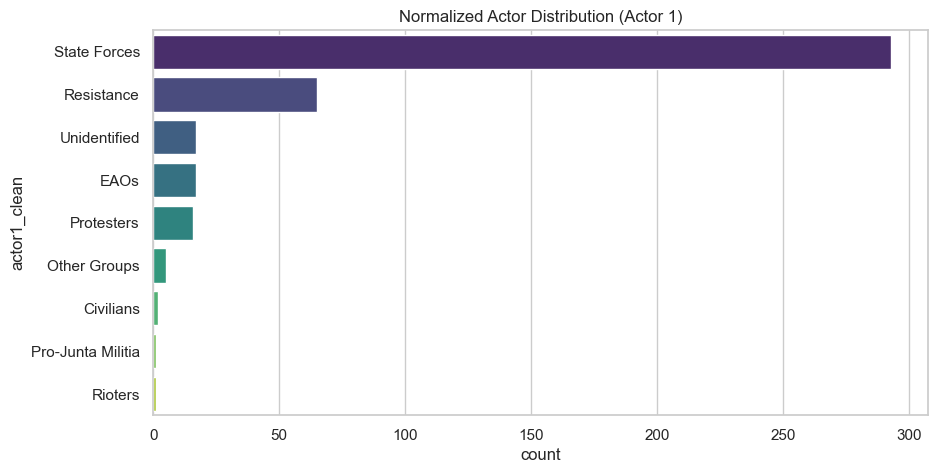

In [2]:
df['actor1_clean'] = df['actor1'].apply(categorize_actor)
df['actor2_clean'] = df['actor2'].apply(categorize_actor)

# Distribution Check
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='actor1_clean', order=df['actor1_clean'].value_counts().index, palette='viridis')
plt.title("Normalized Actor Distribution (Actor 1)")
plt.show()

## 2. Temporal Intensity Analysis
Tracking the volume of events and fatalities over time.

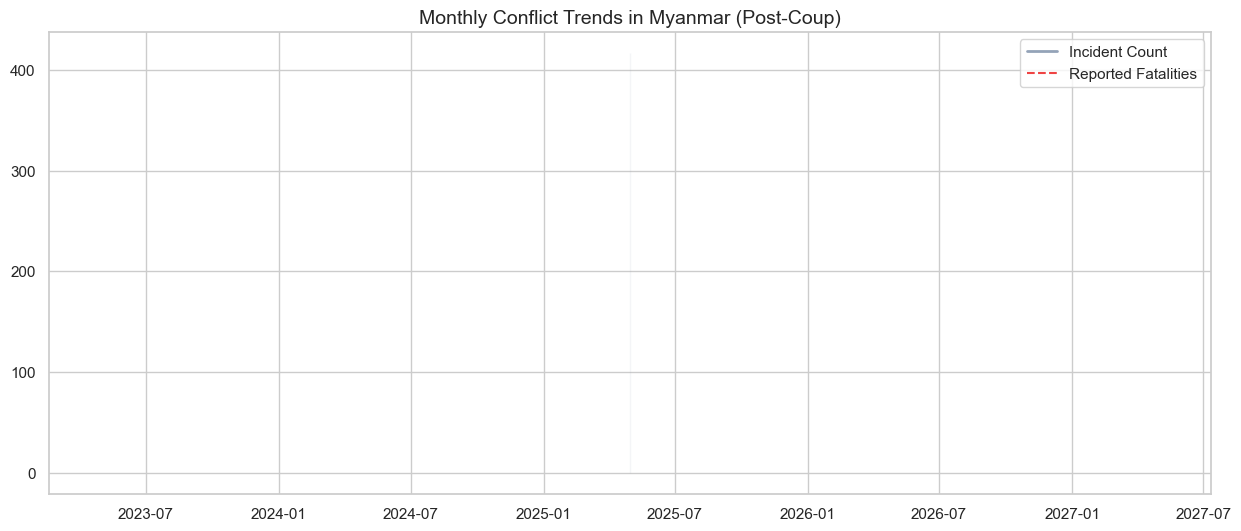

In [3]:
monthly = df.resample('ME', on='event_date').size().reset_index(name='count')
monthly_fat = df.resample('ME', on='event_date')['fatalities'].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(monthly['event_date'], monthly['count'], label='Incident Count', color='#94a3b8', linewidth=2)
plt.fill_between(monthly['event_date'], monthly['count'], color='#94a3b8', alpha=0.1)
plt.plot(monthly_fat['event_date'], monthly_fat['fatalities'], label='Reported Fatalities', color='#ef4444', linestyle='--')
plt.title("Monthly Conflict Trends in Myanmar (Post-Coup)", fontsize=14)
plt.legend()
plt.show()

## 3. Geospatial Stability Assessment
Identifying conflict hotspots and fatalities by region.

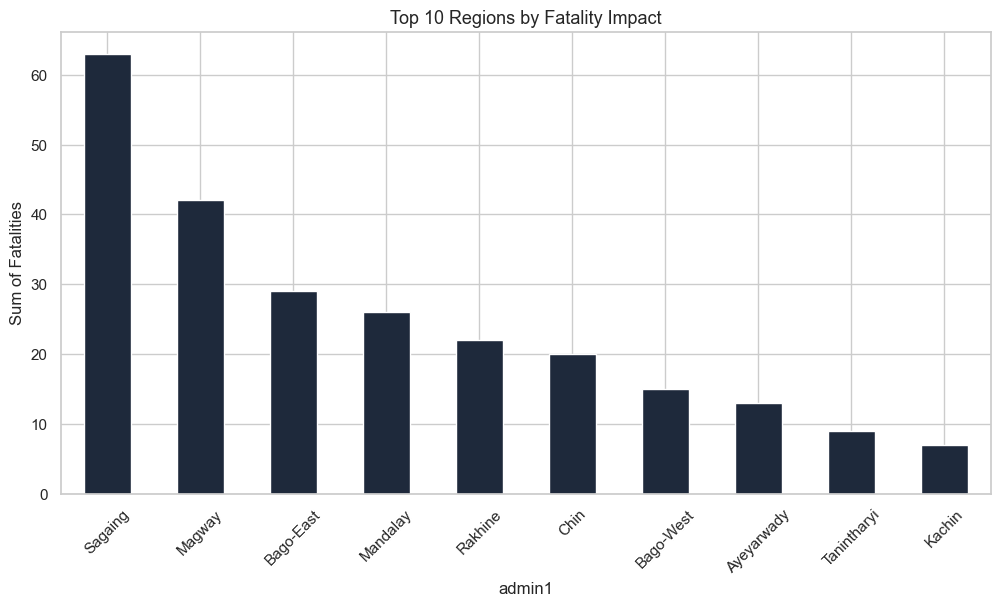

In [4]:
admin_stats = df.groupby('admin1')['fatalities'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
admin_stats.plot(kind='bar', color='#1e293b')
plt.title("Top 10 Regions by Fatality Impact", fontsize=13)
plt.ylabel("Sum of Fatalities")
plt.xticks(rotation=45)
plt.show()

## 4. Advanced Geospatial Visualizations
Interactive Intensity Map and Animated Temporal Spread.

In [5]:
# 1. Incident Intensity Heatmap
fig_heat = px.density_mapbox(
    df, lat='latitude', lon='longitude', z='fatalities', 
    radius=8, center=dict(lat=18.5, lon=96), zoom=5,
    mapbox_style="carto-darkmatter", height=600,
    color_continuous_scale=["#1e293b", "#ef4444"], # Slate to Red
    title="Conflict Intensity Heatmap (Fatality Density)"
)
fig_heat.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, coloraxis_showscale=False)
fig_heat.show()

# 2. Temporal Conflict Evolution (Animation)
df_anim = df.sort_values('event_date')
fig_anim = px.scatter_mapbox(
    df_anim, lat="latitude", lon="longitude", color="actor1_clean",
    size="fatalities", animation_frame="year_month",
    hover_name="location", zoom=5, height=600,
    mapbox_style="carto-darkmatter",
    color_discrete_map={
        "State Forces": "#ef4444", 
        "Resistance": "#3b82f6",
        "EAOs": "#10b981",
        "Civilians": "#94a3b8",
        "Protesters": "#f59e0b",
        "Other Groups": "#475569"
    },
    title="Conflict Evolution in Myanmar (2021-2026)"
)
fig_anim.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_anim.show()